# Part 5: queue (H-64)

Each answer loads a saved run from `metrics/` and makes a plot or a table. The notebook does not need the cluster. Before the measurement sessions, a cell prints "no data yet".

In [1]:
import sys
from pathlib import Path

from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))
from notebook import proof  # noqa: E402

# Run ids in metrics/ (sessions 1 and 2, 2026-09-29). 100% load = RATE100 = 0.9 scripts each second (the E2 knee).
RUNS = {
    "m4_150": "e3-c-150",        # M4 at 150%, layout C (P/D)
    "m1": "e11-pass",            # M1 traffic: M3 with the metrics proxy in pass mode (layout A, 100%)
    "m2": "e6-on",               # M2 shared prefix, prefix cache on (layout C, 100%)
    "m3": "e11-frozen",          # M3: pod B serves a frozen snapshot of an empty pod (layout A, 100%)
    "m4": "e3-c-100",            # M4 mixed interactive and batch (layout C, 100%)
    "m2_prefix_off": "e6-noprefix", "e1_8k": "e1-8k", "e1_24k": "e1-24k",
    "e12_abort": "e12-abort",    # M4 at 100%, 20% of the streams closed in the middle
    "e8_ramp": "e8-a-ramp",      # layout A: pod B restarts, then the warm controller ramps it
    "e8_jump": "e8-a-jump",      # layout A: the returned pod gets the full weight at once
    "e8_warmup": "e8-c-warmup", "e8_immediate": "e8-c-immediate",  # layout C: the one decode pod restarts
    "m2_fp8kv": "e6-fp8kv", "e2_soak": "e2-soak",
    "e14": ["e14-on-int", "e14-off-int", "e14-on-batch", "e14-off-batch"],  # split on/off, retrieve class
}


def show(path):
    if path is None:
        print("no data yet")
    else:
        display(Image(filename=str(path)))


## H-65: Who sits in our queue and who sits in the vLLM waiting queue?

Our queue is the flow-control queue of the llm-d router. A request waits there before the pick, in its priority band (interactive 10, batch 0) and for its tenant. The vLLM waiting queue holds a request after the pick, inside one pod. In `e3-c-150` (M4 at 150% load, layout C), our queue held up to 48 interactive and 24 batch requests. The vLLM waiting queue of the decode pod held up to 50 requests, and the prefill pod held up to 8. Most agent calls have fewer than 2,048 new tokens, so the router does not split them, and the decode pod also computes their prompts.

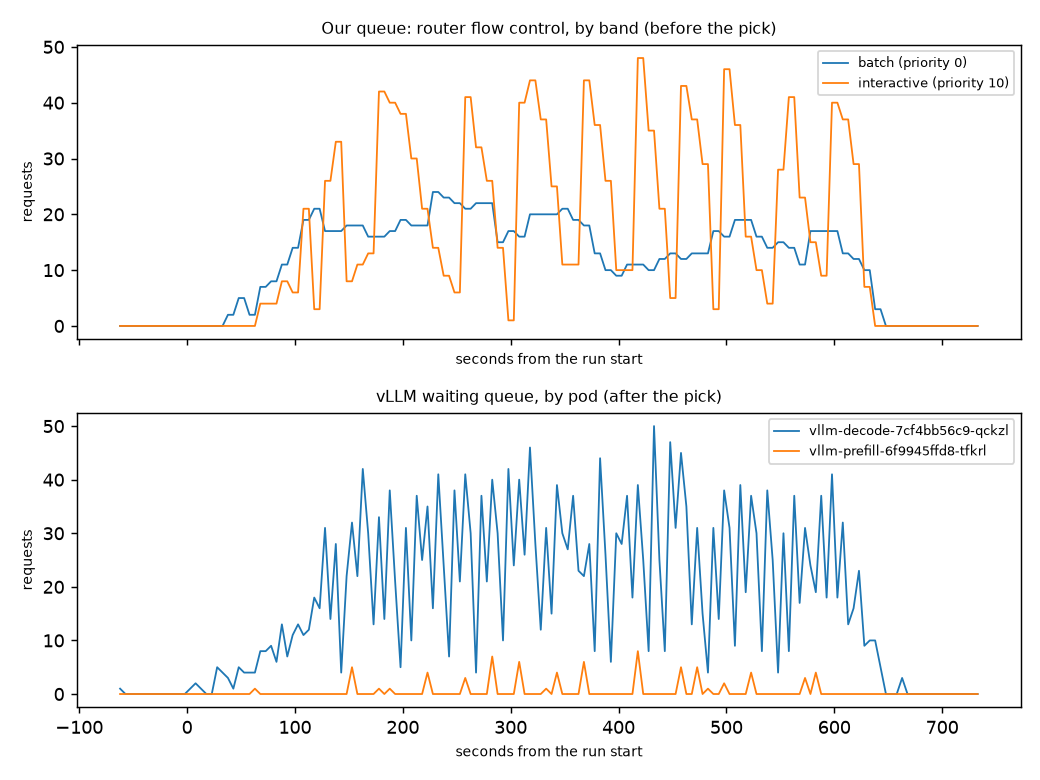

In [2]:
show(proof.queue_before_and_after_pick(proof.load_run(RUNS["m4_150"])))

## H-66: Show waiting, running, and preempted counts (V1 has no swap).

vLLM V1 preempts by recompute. In `e3-c-150`, the decode pod ran 24 requests at most (its `--max-num-seqs`), and up to 50 waited. The prefill pod ran 4 at most. No pod preempted a request. The router flow control held the load at the door, and the KV use of the decode pod stayed at 90% or less.

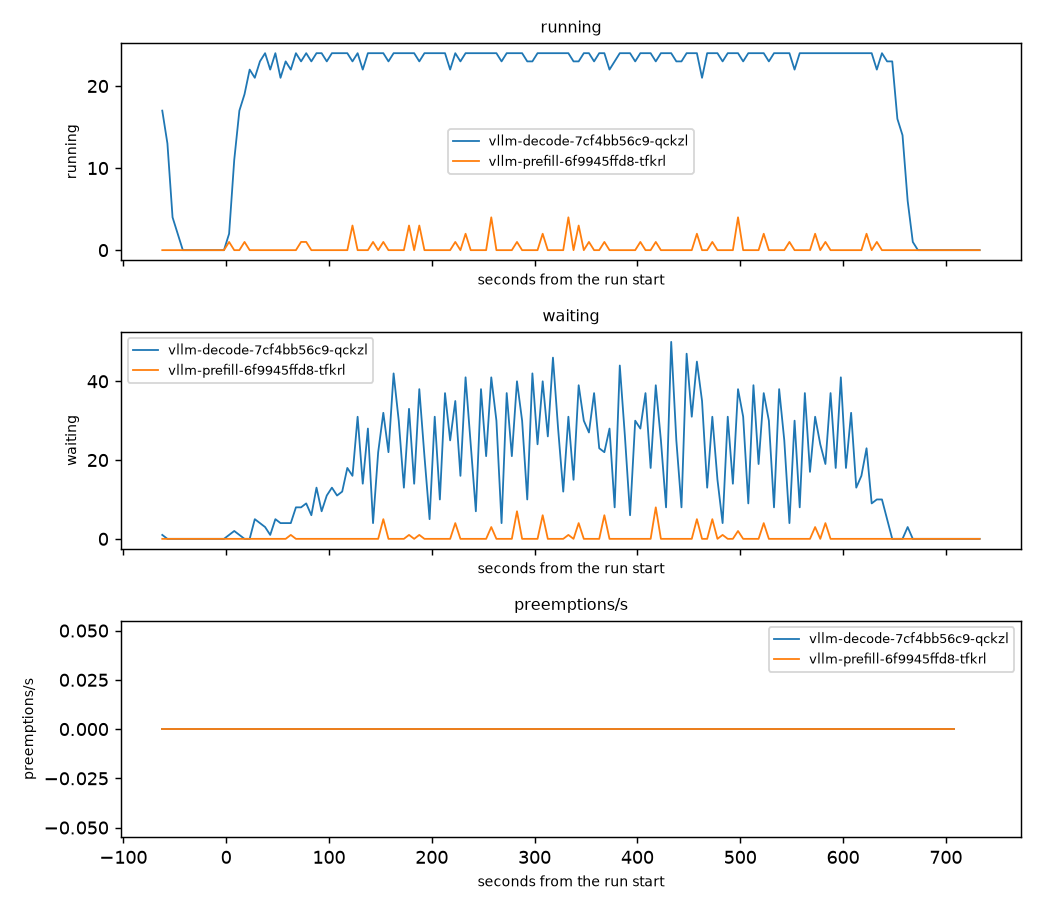

In [3]:
show(proof.engine_counts(proof.load_run(RUNS["m4_150"])))

## H-67: Show the queue depth for each pod under each traffic mix.

Our `orch_replica_queue_depth` is the router view of the queue of each pod (`router_pod_queue`), next to `vllm:num_requests_waiting`. At 100% load (0.9 scripts each second): M1 and M3 (layout A) kept 2 or fewer requests in each queue. M2 kept 6 or fewer. M4 (layout C) put up to 36 requests in the router queue of the decode pod, and up to 38 in its vLLM waiting queue. The prefill pod stayed at 9 or fewer.

m1 e11-pass


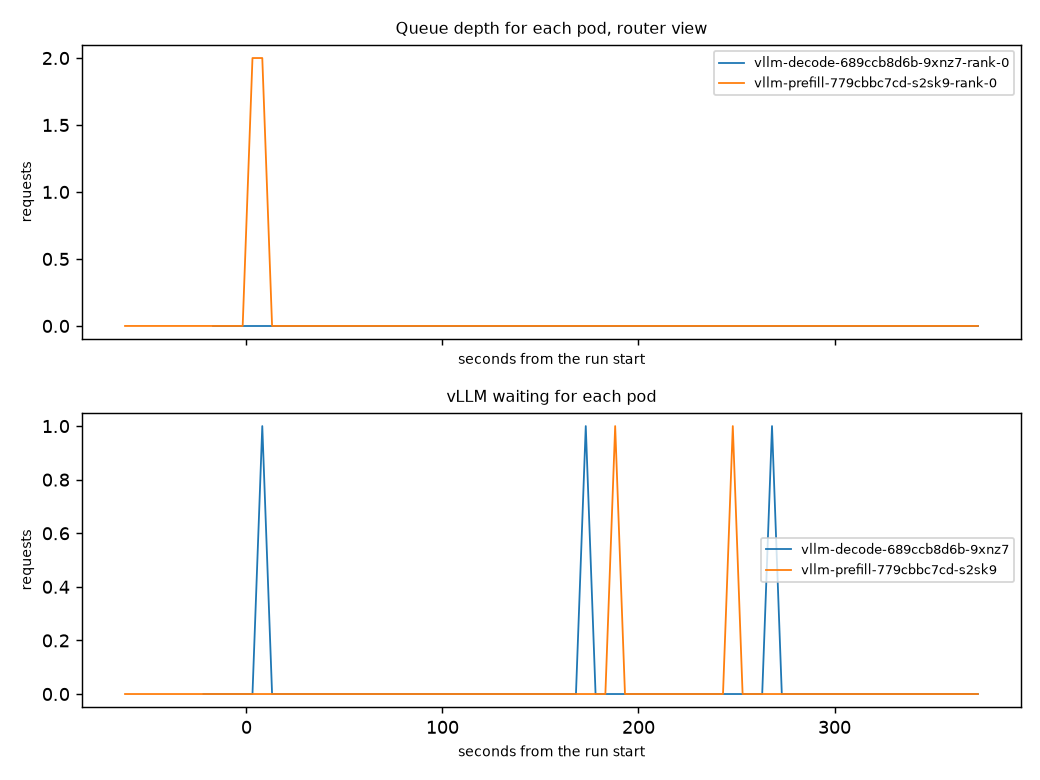

m2 e6-on


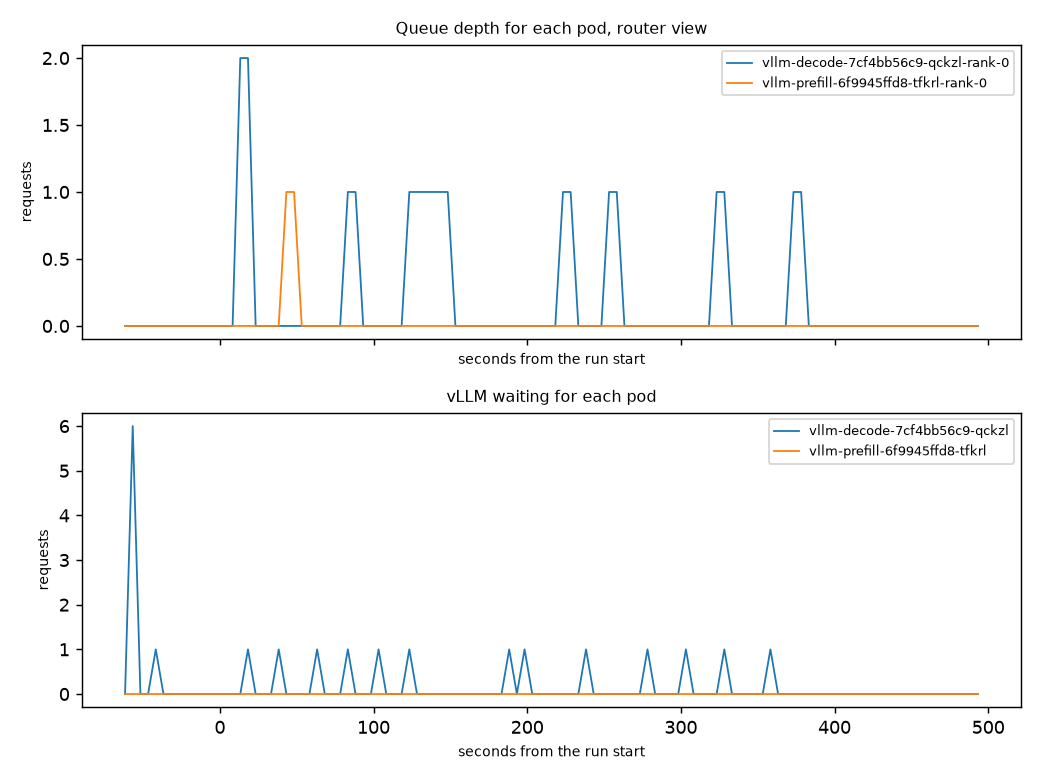

m3 e11-frozen


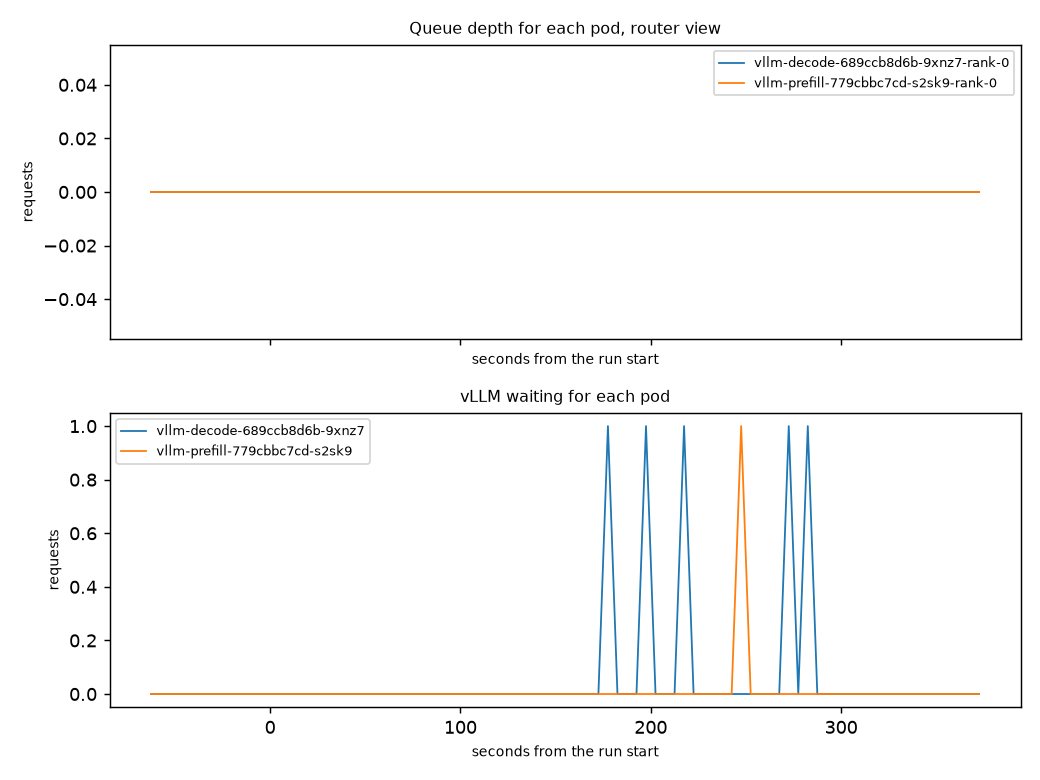

m4 e3-c-100


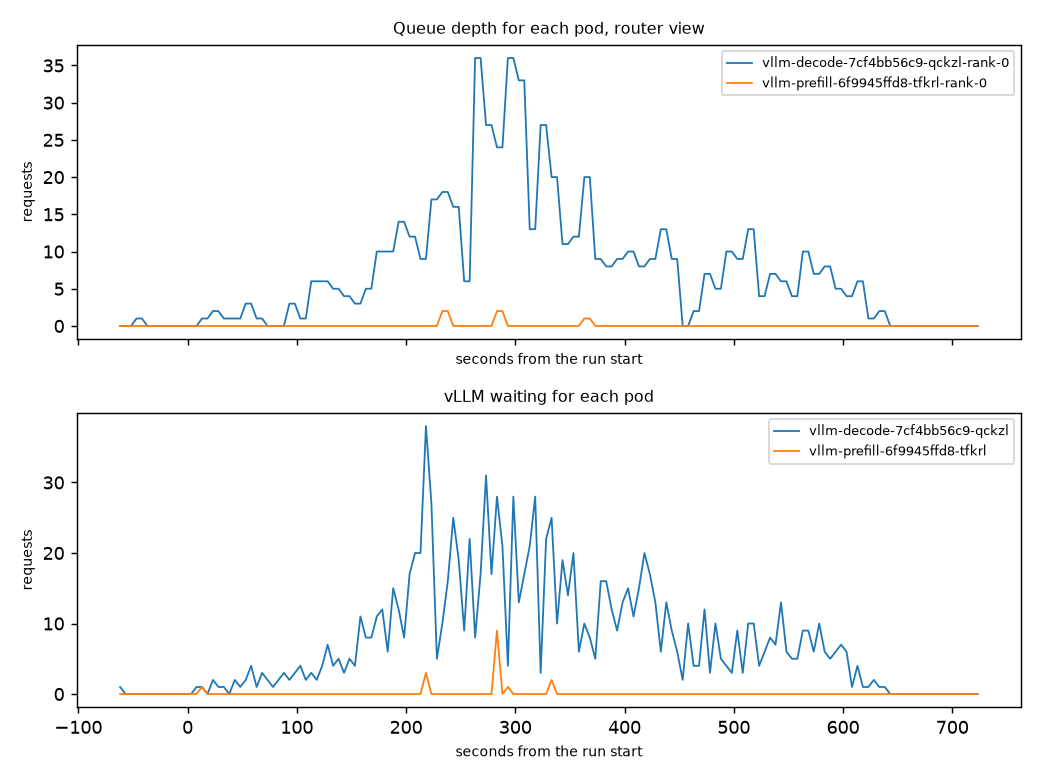

In [4]:
for mix in ("m1", "m2", "m3", "m4"):
    print(mix, RUNS[mix])
    show(proof.queue_depth_by_pod(proof.load_run(RUNS[mix])))

## H-68: If a 32K RAG retrieve and a short agent decode are both ready, who goes first?

E14 sends a retrieve of about 27,400 tokens and five short agent steps at the same time. Each arm has five rounds. In all rounds of all arms, an agent step got the first token. Our queue gives priority by class.

The P/D split decides the cost. With the split, the long prefill runs on the prefill pod, and the agent steps start in 0.25 s (median). With no split, the long prompt shares the decode pod, and the agent steps need 1.0 to 1.26 s.

{'run': 'e14-on-int', 'retrieve_class': 'interactive', 'retrieve_ttft_median_s': 3.6589, 'agent_step_ttft_median_s': 0.2484, 'agent_step_end_median_s': 0.6614, 'first_token_to_agent_step': '5 of 5 rounds'}
{'run': 'e14-off-int', 'retrieve_class': 'interactive', 'retrieve_ttft_median_s': 3.0027, 'agent_step_ttft_median_s': 1.2643, 'agent_step_end_median_s': 3.5292, 'first_token_to_agent_step': '5 of 5 rounds'}
{'run': 'e14-on-batch', 'retrieve_class': 'batch', 'retrieve_ttft_median_s': 3.6551, 'agent_step_ttft_median_s': 0.2433, 'agent_step_end_median_s': 0.6635, 'first_token_to_agent_step': '5 of 5 rounds'}
{'run': 'e14-off-batch', 'retrieve_class': 'batch', 'retrieve_ttft_median_s': 3.0205, 'agent_step_ttft_median_s': 1.015, 'agent_step_end_median_s': 3.4804, 'first_token_to_agent_step': '5 of 5 rounds'}


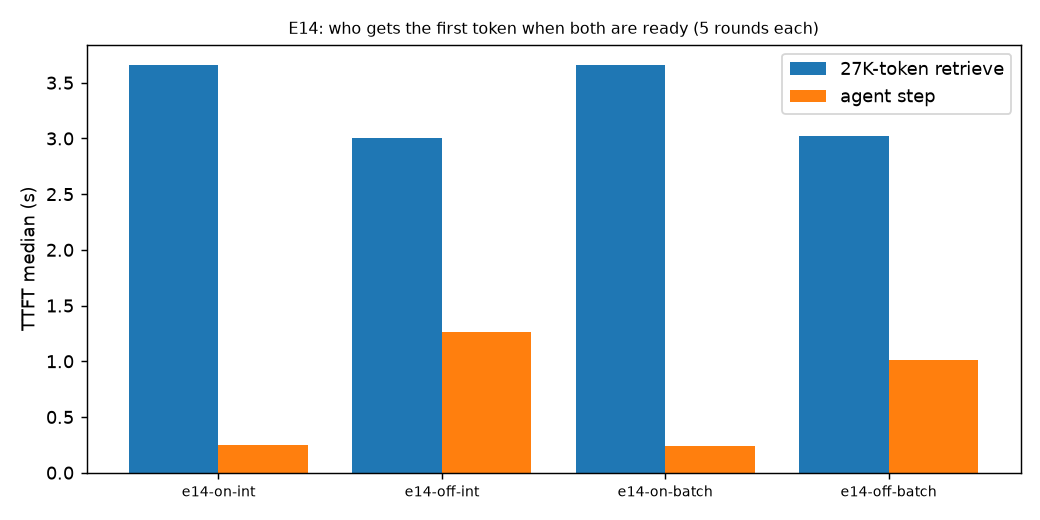

In [5]:
for row in proof.queue_order(RUNS["e14"]):
    print(row)
show(proof.queue_order_plot(RUNS["e14"]))

## H-69: PagedAttention packs KV. Prefix cache reuses KV. Which one saved memory on our shared-prefix mix?

E6 runs M2 at 100% load in three arms: the GPU prefix cache on, off, and on with fp8 KV. PagedAttention packs the KV in all arms. The KV use of the decode pod was 13% on average. At this load, the prefix cache did not save memory.

The prefix cache saved prefill work. On the decode pod, 44% of the prompt tokens were cache hits. The TTFT p50 went from 0.60 s (off) to 0.43 s (on). With the GPU prefix cache off, the LMCache tier gave back most of the hits: about 4,500 tokens each second in both arms.

fp8 KV saved memory. The mean KV use fell to 5.5%, and each pod held twice the tokens (345,235 against 173,657).

{'run': 'e6-on', 'decode_kv_use_mean': 0.135, 'decode_kv_use_max': 0.57, 'decode_prefix_hit_ratio_mean': 0.441, 'lmcache_hit_tokens_per_s_mean': 4374, 'interactive_ttft_p50_s': 0.4348, 'interactive_ttft_p95_s': 1.2806}
{'run': 'e6-noprefix', 'decode_kv_use_mean': 0.133, 'decode_kv_use_max': 0.452, 'decode_prefix_hit_ratio_mean': None, 'lmcache_hit_tokens_per_s_mean': 4471, 'interactive_ttft_p50_s': 0.599, 'interactive_ttft_p95_s': 1.2912}
{'run': 'e6-fp8kv', 'decode_kv_use_mean': 0.055, 'decode_kv_use_max': 0.26, 'decode_prefix_hit_ratio_mean': 0.677, 'lmcache_hit_tokens_per_s_mean': 5747, 'interactive_ttft_p50_s': 0.2299, 'interactive_ttft_p95_s': 1.7652}


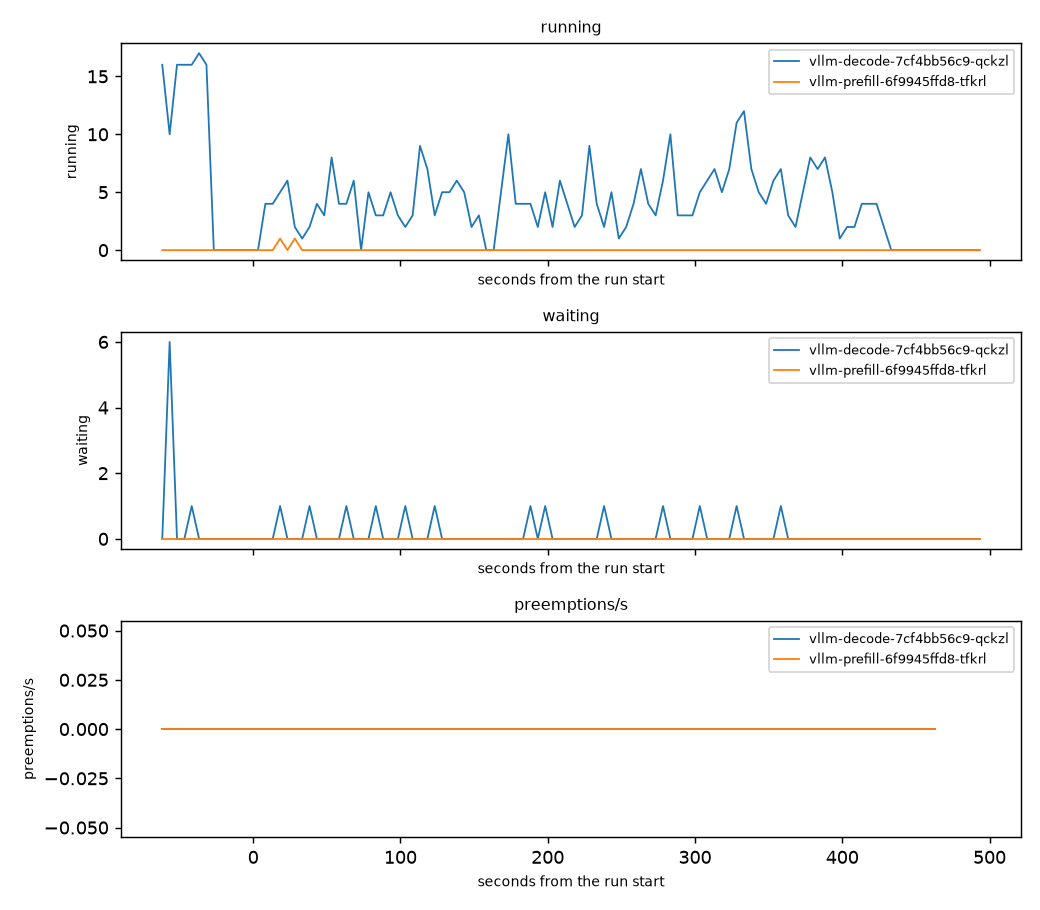

In [6]:
for row in proof.kv_table([proof.load_run(RUNS[k]) for k in ("m2", "m2_prefix_off", "m2_fp8kv")]):
    print(row)
show(proof.engine_counts(proof.load_run(RUNS["m2"])))

## H-70: Give the engine flags for chunked prefill and continuous batching, and the reason for each value.

The flags come from the run record of `e3-c-100`. The reasons are in `docs/spec/04-system-design.md`, section 3. The decode pod has `--max-num-seqs=24`, because its KV holds about 20 sequences at 24K tokens. With `--max-num-batched-tokens=2560`, it runs a prefill below the split threshold in one chunk. The threshold is 2,048 uncached tokens. vLLM refuses a value below the largest image item of Gemma 4 (2,496 tokens).

The prefill pod has `--max-num-seqs=8`, because its requests leave after the hop. It has `--max-num-batched-tokens=16384`: large chunks for throughput. Both pods use `--scheduling-policy=priority`, `--enable-prefix-caching`, and `--block-size=64`.

E15 changed one value at a time. With 32 decode sequences, the interactive TTFT p50 fell from 4.59 s to 2.10 s, so E3 runs again with 32. A prefill chunk of 8,192 tokens made it worse (8.50 s).

In [7]:
flags = proof.engine_flags(proof.load_run(RUNS["m4"]))
for pod, args in flags.items():
    print(pod)
    print("   ", " ".join(a for a in args if a.startswith("--max") or a.startswith("--sched")))

vllm-decode-7cf4bb56c9-qckzl
    --max-model-len=32768 --max-num-seqs=24 --max-num-batched-tokens=2560 --scheduling-policy=priority
vllm-prefill-6f9945ffd8-tfkrl
    --max-model-len=32768 --max-num-seqs=8 --max-num-batched-tokens=16384 --scheduling-policy=priority


## H-71: If the KV is full after admit, do we shed at the door or does the engine preempt?

We shed at the door. The soak (E2) adds 0.05 scripts each second each minute. The first capacity shed came in minute 18 (503 `timeout_queue`): this is RATE100, 0.9 scripts each second. In the whole soak, 3,645 calls were ok, and the router shed 43. The KV use of the decode pod stayed at 90% or less, and no pod preempted a request.

{'rate100': 0.9, 'first_shed_s': 1082.6, 'shed_minute': 18, 'reason': '503 timeout_queue'}


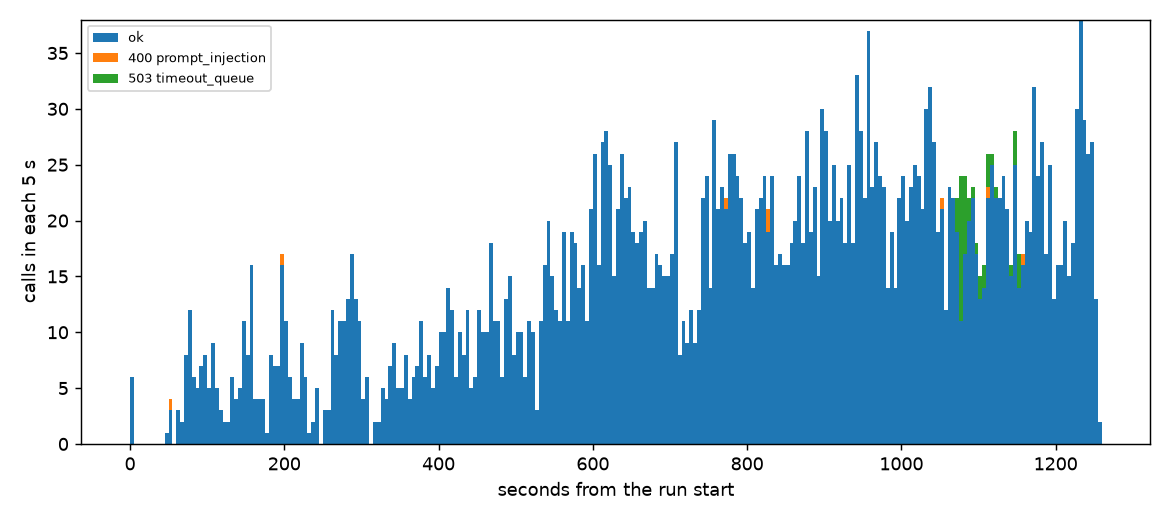

In [8]:
print(proof.knee_rate(proof.load_run(RUNS["e2_soak"])))
show(proof.soak(proof.load_run(RUNS["e2_soak"])))

## H-72: If the client is gone (aborted), who frees the KV and how?

E12 closes 20% of the streams in the middle (46 calls). Envoy closed each of the 46 streams at the time of the client close, and it got no usage data for them. The vLLM API server sees the closed stream. Then `abort_requests` stops the request in the engine. The engine frees its KV blocks. vLLM v0.30.0 does not count these aborts in `vllm:request_success_total{finished_reason="abort"}` (`vllm/v1/engine/output_processor.py`, `abort_requests`), so that counter stays at 0.

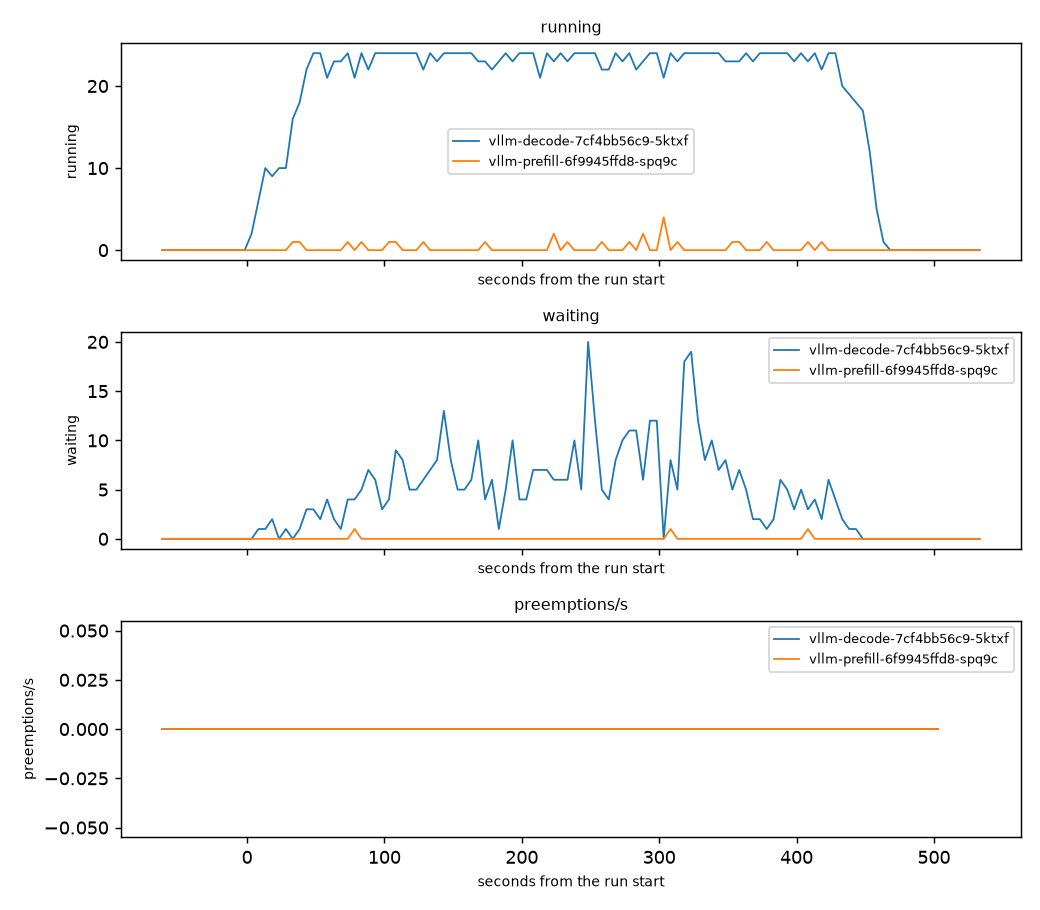

In [9]:
show(proof.engine_counts(proof.load_run(RUNS["e12_abort"])))

## H-73: After a worker returns, do we send 100% at once, or do we ramp while p99 holds?

We ramp. The warm controller gives a returned pod the ramp label r10. While the TTFT p99 of the pod holds, the label goes to r25, r50, and r100. The router has a ramp scorer for this label.

E8 in layout A deletes pod B at 180 s. With the ramp, the TTFT p95 of the returned pod in its first minute was 14.6 s. With a jump to 100%, it was 57.3 s. The ramp is a score, not a cap. In the first 10 s, the empty pod got 75% of the calls, because the queue scorer prefers it.

In layout C, the one decode pod was down, and 182 to 184 calls got 503 `no_endpoints`. With the warmup routine, the TTFT p95 in the first minute of the new pod was 7.3 s. With no warmup, it was 10.9 s.

{'run': 'e8-a-ramp', 'new_pod': '10.42.1.53:8000', 'back_at_s': 456, 'outage_s': None, 'no_endpoint_calls': 0, 'first_minute': {'calls': 172, 'ttft_p50_s': 5.11, 'ttft_p95_s': 14.611, 'prompt_tokens_p50': 2527, 'cached_share': 0.41}, 'minutes_2_to_4': {'calls': 83, 'ttft_p50_s': 1.062, 'ttft_p95_s': 6.606, 'prompt_tokens_p50': 2310, 'cached_share': 0.43}, 'share_10s': {-30: 0.0, -20: 0.0, -10: 0.0, 0: 0.75, 10: 0.19, 20: 0.45, 30: 0.51, 40: 0.55, 50: 0.51, 60: 0.53, 70: 0.52, 80: 0.53, 90: 0.57, 100: 0.43, 110: 0.54, 120: 0.45, 130: 0.44, 140: 0.68, 150: 0.46, 160: 1.0}}
{'run': 'e8-a-jump', 'new_pod': '10.42.1.54:8000', 'back_at_s': 412, 'outage_s': None, 'no_endpoint_calls': 0, 'first_minute': {'calls': 43, 'ttft_p50_s': 10.418, 'ttft_p95_s': 57.295, 'prompt_tokens_p50': 2392, 'cached_share': 0.45}, 'minutes_2_to_4': {'calls': 121, 'ttft_p50_s': 0.917, 'ttft_p95_s': 8.53, 'prompt_tokens_p50': 2455, 'cached_share': 0.46}, 'share_10s': {-30: 0.0, -20: 0.0, -10: 0.0, 0: 0.13, 10: 0.03, 

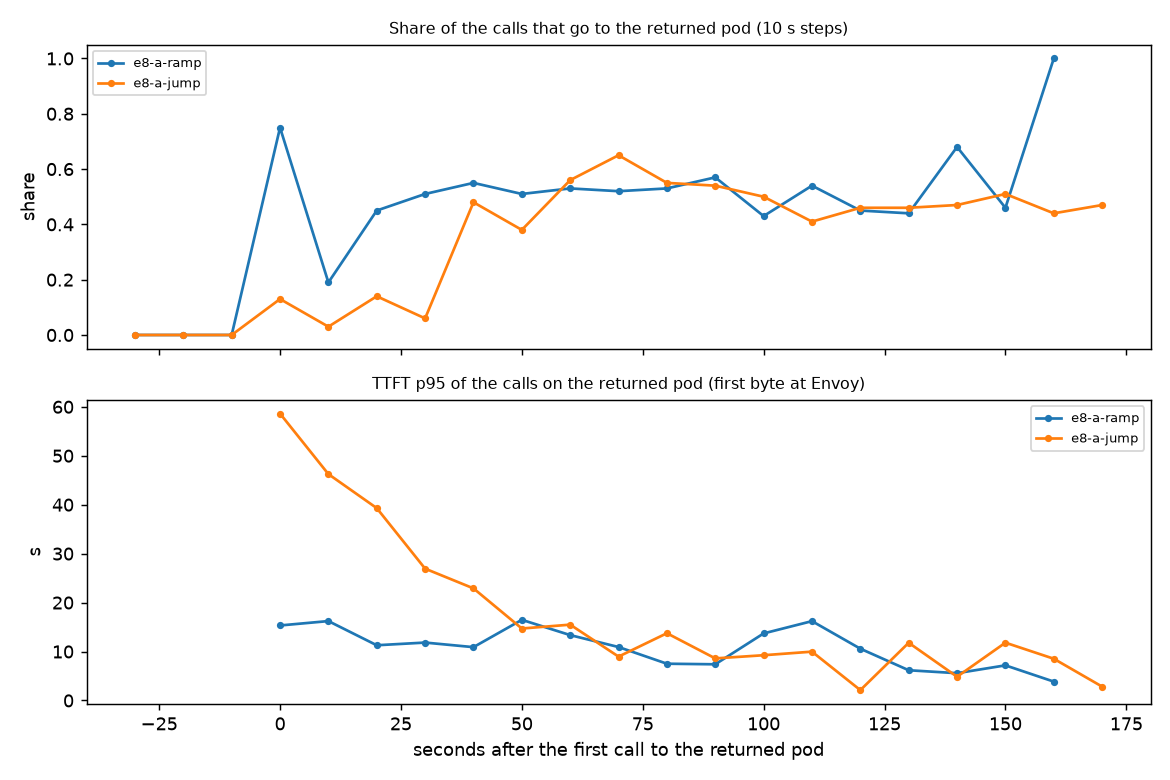

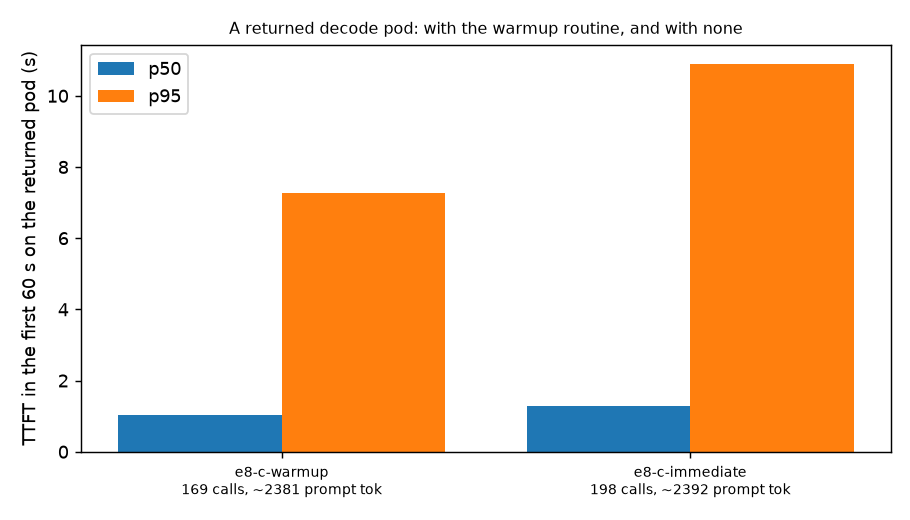

In [10]:
for key in ("e8_ramp", "e8_jump", "e8_warmup", "e8_immediate"):
    print(proof.new_pod_window(proof.load_run(RUNS[key])))
show(proof.new_pod_plot([proof.load_run(RUNS[k]) for k in ("e8_ramp", "e8_jump")], name="e8-a-new-pod.png"))
show(proof.warmup_first_minute([proof.load_run(RUNS[k]) for k in ("e8_warmup", "e8_immediate")]))